# DBSCAN Clustering of Customers

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Goal: use density-based clustering (DBSCAN) to group customers by income and spending, and let the algorithm flag outliers automatically as noise.

## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset

41 normal customers with incomes 15k–35k (step 0.5) plus 3 high-income outliers at 80k/85k/90k. Spending scores follow a roughly linear upward trend with income so the normal customers form one elongated dense band.

In [2]:
annual_income = [
    15, 15.5, 16, 16.5, 17, 17.5, 18, 18.5, 19, 19.5,
    20, 20.5, 21, 21.5, 22, 22.5, 23, 23.5, 24, 24.5,
    25, 25.5, 26, 26.5, 27, 27.5, 28, 28.5, 29, 29.5,
    30, 30.5, 31, 31.5, 32, 32.5, 33, 33.5, 34, 34.5,
    35,
    80, 85, 90,  # outliers
]

spending_score = [
    39, 42, 45, 48, 51, 54, 57, 60, 63, 66,
    68, 70, 72, 73, 75, 76, 78, 79, 80, 82,
    83, 84, 85, 86, 87, 87, 88, 88, 89, 89,
    90, 91, 92, 93, 94, 95, 95, 96, 97, 98,
    99,
    40, 60, 80,  # outliers' spending scores
]

df = pd.DataFrame({
    'AnnualIncome':  annual_income,
    'SpendingScore': spending_score,
})
df.head()

,AnnualIncome,SpendingScore
0,15.0,39
1,15.5,42
2,16.0,45
3,16.5,48
4,17.0,51


### Raw data — what we're feeding DBSCAN

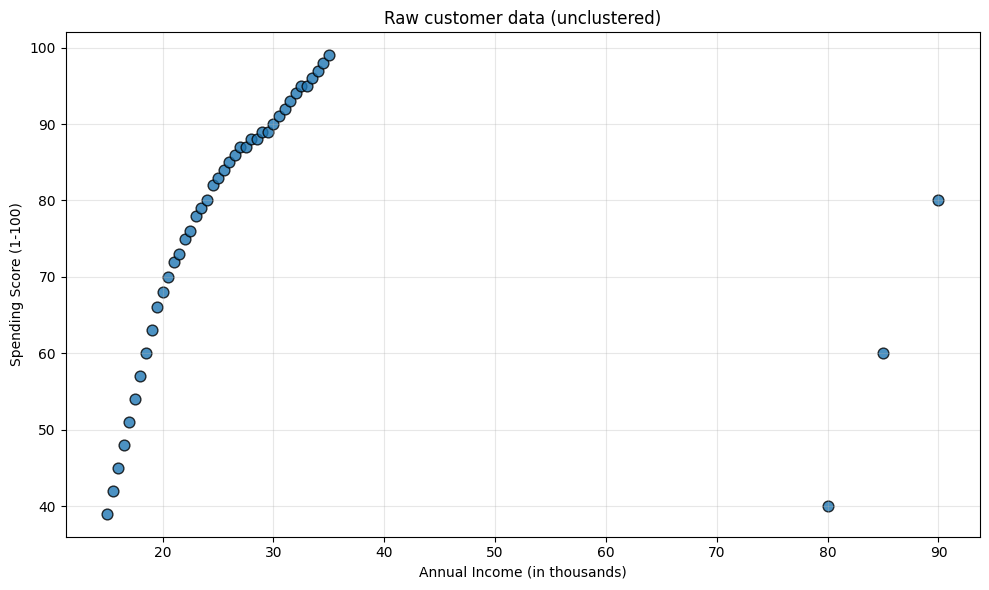

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], s=60, edgecolor='k', alpha=0.8)
plt.title('Raw customer data (unclustered)')
plt.xlabel('Annual Income (in thousands)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preprocess — scale the features

DBSCAN uses Euclidean distance, so features with larger ranges dominate the `eps` neighborhood. Scale to zero mean / unit variance.

In [4]:
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled_array, columns=['AnnualIncome', 'SpendingScore'])
df_scaled.head()

,AnnualIncome,SpendingScore
0,-0.869761,-2.175423
1,-0.838899,-2.001178
2,-0.808036,-1.826933
3,-0.777174,-1.652688
4,-0.746311,-1.478443


## 5. Run DBSCAN with the default parameters

- `eps=0.5` — points within this distance (in scaled space) are neighbors.
- `min_samples=3` — a core point needs at least 3 neighbors (including itself).
- Points DBSCAN can't assign to any cluster get label **-1 (noise)**.

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan.fit(df_scaled)
df['Cluster'] = dbscan.labels_

n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = int((dbscan.labels_ == -1).sum())
print(f'Found {n_clusters} cluster(s), {n_noise} noise point(s)')
print(f'Cluster sizes: {df["Cluster"].value_counts().sort_index().to_dict()}')
print('\nNoise (outlier) rows:')
df[df['Cluster'] == -1]

Found 1 cluster(s), 3 noise point(s)
Cluster sizes: {-1: 3, 0: 41}

Noise (outlier) rows:


,AnnualIncome,SpendingScore,Cluster
41,80.0,40,-1
42,85.0,60,-1
43,90.0,80,-1


## 6. Visualize the clusters

Noise points (-1) get their own black ✕ marker so they're easy to spot.

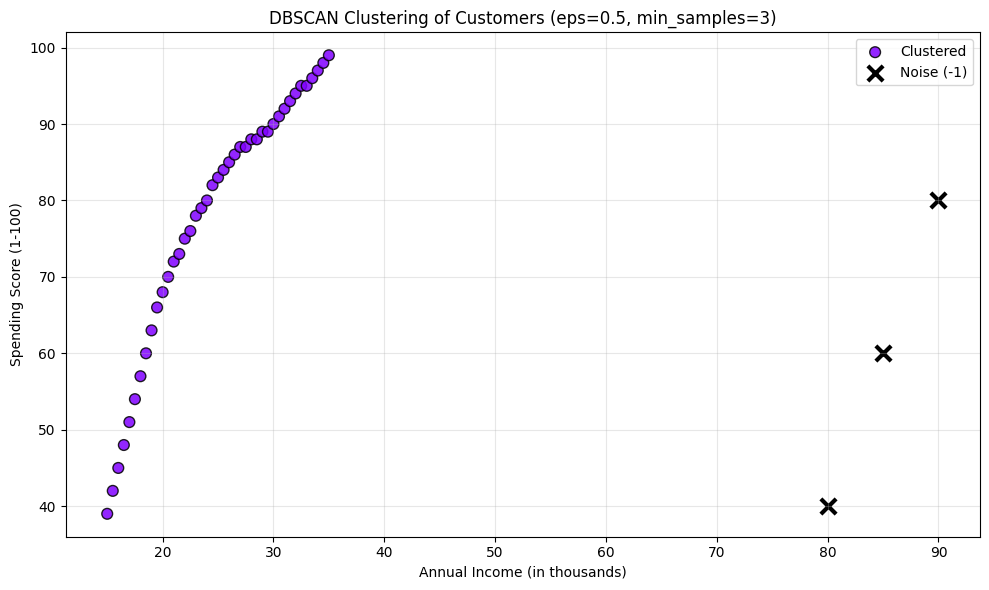

In [6]:
def plot_clusters(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    noise_mask = df['Cluster'] == -1
    ax.scatter(
        df.loc[~noise_mask, 'AnnualIncome'],
        df.loc[~noise_mask, 'SpendingScore'],
        c=df.loc[~noise_mask, 'Cluster'], cmap='rainbow',
        s=60, edgecolor='k', alpha=0.85, label='Clustered',
    )
    if noise_mask.any():
        ax.scatter(
            df.loc[noise_mask, 'AnnualIncome'],
            df.loc[noise_mask, 'SpendingScore'],
            c='black', marker='x', s=120, linewidths=3, label='Noise (-1)',
        )
    ax.set_title(title)
    ax.set_xlabel('Annual Income (in thousands)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_clusters(df, 'DBSCAN Clustering of Customers (eps=0.5, min_samples=3)')

## 7. Tune the parameters

Sweep `eps` and `min_samples` and watch what happens:

In [7]:
print(f"{'eps':>6s}  {'min_samples':>11s}  {'clusters':>9s}  {'noise pts':>10s}")
for eps_val in [0.3, 0.5, 0.7, 1.0]:
    for ms in [3, 5]:
        m = DBSCAN(eps=eps_val, min_samples=ms).fit(df_scaled)
        nc = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
        nn = int((m.labels_ == -1).sum())
        print(f'{eps_val:>6.2f}  {ms:>11d}  {nc:>9d}  {nn:>10d}')

   eps  min_samples   clusters   noise pts
  0.30            3          1           3
  0.30            5          1          11
  0.50            3          1           3
  0.50            5          1           3
  0.70            3          1           3
  0.70            5          1           3
  1.00            3          1           3
  1.00            5          1           3


### Same plot with eps=0.7 (activity's suggested follow-up)

Found 1 cluster(s), 3 noise point(s)


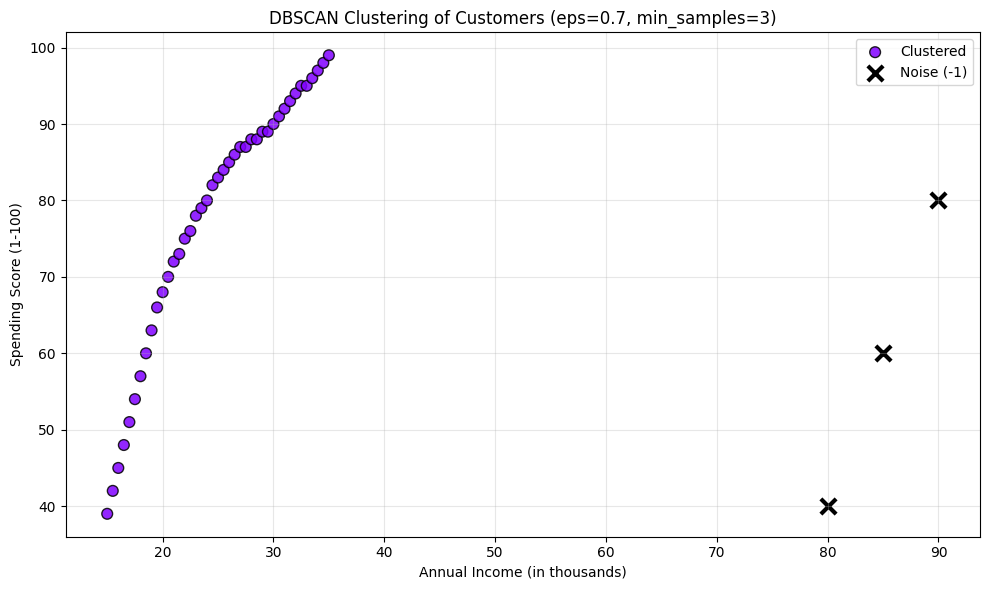

In [8]:
dbscan_07 = DBSCAN(eps=0.7, min_samples=3).fit(df_scaled)
df['Cluster'] = dbscan_07.labels_

n_clusters_07 = len(set(dbscan_07.labels_)) - (1 if -1 in dbscan_07.labels_ else 0)
n_noise_07 = int((dbscan_07.labels_ == -1).sum())
print(f'Found {n_clusters_07} cluster(s), {n_noise_07} noise point(s)')

plot_clusters(df, 'DBSCAN Clustering of Customers (eps=0.7, min_samples=3)')

## Key takeaways

- **DBSCAN groups by density.** A *core point* has at least `min_samples` neighbors within distance `eps`. Points reachable from a core join the cluster; everything else is **noise (-1)**.
- **No k to pick.** Clusters fall out of the density structure of the data — that's why DBSCAN can find arbitrarily-shaped clusters (crescents, rings) that K-means can't.
- **Outlier detection is free.** Compare to K-means on the same data: K-means *forces* the 3 outliers into their own cluster. DBSCAN simply labels them noise, which is usually what you want for outlier work.
- **`eps` is the dial that matters most.** Too small → many noise points; too large → distinct clusters merge. The standard heuristic is the **k-distance plot**: sort the distance to the k-th nearest neighbor for each point, find the elbow.
- **Scale first.** DBSCAN uses Euclidean distance — unscaled features make `eps` meaningless.
- On this dataset, eps in [0.5, 1.0] with `min_samples=3` cleanly isolates exactly the 3 high-income outliers as noise.